In [1]:
import ccxt
import pandas as pd
# 更簡潔的引入方式 - 直接從套件引入類別
from src import Create_funding_fetcher,Create_klines_fetcher,FundingFetcher,KlinesFetcher
# 使用套件定義的常數
from pipeline import DataMerge, DataTransform
from backtest import Backtester
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
exchange1 = 'binance'
exchange2 = 'okx'
exchange3 = 'gateio'

## Backtest 

### binance & okx

In [20]:
from utils import find_symbols_missing_klines

In [12]:
binance_okx = Backtester(exchange1, exchange2)

Backtester: Cross-exchange mode: binance vs okx | Symbols: 223


In [22]:
def plot_long_ls(df, symbol):
    long_df = df[df['signal'] == 1]
    short_df = df[df['signal'] == -1]
    
    # Check if both DataFrames are empty
    if long_df.empty and short_df.empty:
        print(f"No trades found for {symbol}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=300)
    
    # Calculate shared y-axis limits only from non-empty DataFrames
    y_values = []
    if not long_df.empty:
        y_values.extend([long_df.cumulative_pnl_with_fee_no_spread.min(), 
                        long_df.cumulative_pnl_with_fee_no_spread.max()])
    if not short_df.empty:
        y_values.extend([short_df.cumulative_pnl_with_fee_no_spread.min(), 
                        short_df.cumulative_pnl_with_fee_no_spread.max()])
    
    y_min = min(y_values) if y_values else 0
    y_max = max(y_values) if y_values else 1
    
    # Long position subplot
    if not long_df.empty:
        ax1.plot(long_df.Time, long_df.cumulative_pnl_with_fee_no_spread, 
                 color='#2ca02c', linewidth=2, label='Long Position', alpha=0.9)
        ax1.set_xlim(long_df['Time'].min(), long_df['Time'].max())
    else:
        ax1.text(0.5, 0.5, 'No Long Positions', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=14, color='gray')
    
    ax1.set_title(f'{symbol} Long Position PnL Over Time', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Date', fontsize=13, fontweight='500')
    ax1.set_ylabel('Cumulative PnL', fontsize=13, fontweight='500')
    ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
    ax1.set_ylim(y_min, y_max)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='gray')
    ax1.tick_params(axis='x', rotation=45)
    
    # Short position subplot
    if not short_df.empty:
        ax2.plot(short_df.Time, short_df.cumulative_pnl_with_fee_no_spread, 
                 color='#ff5733', linewidth=2, label='Short Position', alpha=0.9)
        ax2.set_xlim(short_df['Time'].min(), short_df['Time'].max())
    else:
        ax2.text(0.5, 0.5, 'No Short Positions', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=14, color='gray')
    
    ax2.set_title(f'{symbol} Short Position PnL Over Time', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Date', fontsize=13, fontweight='500')
    ax2.set_ylabel('Cumulative PnL', fontsize=13, fontweight='500')
    ax2.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
    ax2.set_ylim(y_min, y_max)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='gray')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [23]:
def coin_analysis(coin_porfolio_df, top_n=20):
    """Plot top N coins showing waterfall breakdown: base PnL, fees, and spread impact."""
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    
    # Calculate cumulative components
    cumulative_base = coin_porfolio_df[0].sum(axis=0)
    cumulative_no_spread = coin_porfolio_df[1].sum(axis=0)
    cumulative_total = coin_porfolio_df[2].sum(axis=0)
    
    fee_impact = cumulative_no_spread - cumulative_base
    spread_impact = cumulative_total - cumulative_no_spread
    
    # Select and sort top N
    top_symbols = cumulative_total.abs().nlargest(top_n).index
    sorted_idx = cumulative_total[top_symbols].sort_values(ascending=False).index
    
    print(f"\nComponent Breakdown for Top {top_n} Coins:")
    print(f"{'Symbol':<12} {'Base':>8} {'Fees':>8} {'Spread':>8} {'Total':>8}")
    print("="*50)
    for sym in sorted_idx:
        print(f"{sym:<12} {cumulative_base[sym]*100:>7.2f}% {fee_impact[sym]*100:>7.2f}% "
              f"{spread_impact[sym]*100:>7.2f}% {cumulative_total[sym]*100:>7.2f}%")

In [24]:
def L_S_analysis(df):
    long_entries = df[df['signal'] == 1]
    
    short_entries = df[df['signal'] == -1]
    
    if long_entries.empty:
        long_pnl = 0.0
    else:
            long_pnl = float(long_entries.cumulative_pnl_with_fee_no_spread.tail(1).values[0])

    if short_entries.empty:
        short_pnl = 0.0
    else:
            short_pnl = float(short_entries.cumulative_pnl_with_fee_no_spread.tail(1).values[0])

    return long_pnl, short_pnl

In [25]:
def plot_coin_performance(all_symbol_df, symbol=None, title=None, figsize=(18, 7), plot_all=False):
    """
    Plot cumulative PnL for coins (with spread only).
    
    Args:
        all_symbol_df: List of 3 DataFrames [base_pnl, fee_no_spread, total_fee]
        symbol: Symbol to plot (e.g., 'BNB/USDT'). Ignored if plot_all=True
        title: Custom title
        figsize: Figure size (default: (18, 7))
        plot_all: If True, plot all symbols on one plot (default: False)
    """
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np
    
    plt.style.use('default')
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 300
    
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    
    if plot_all:
        # Plot all symbols on same plot
        symbols = all_symbol_df[2].columns.tolist()
        
        for sym in symbols:
            ax.plot(all_symbol_df[2].index, all_symbol_df[2][sym].cumsum(), 
                    linewidth=1.5, label=sym, alpha=0.8)
        
        ax.set_title(title or 'All Symbols PnL Over Time', fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='best', fontsize=9, ncol=3, framealpha=0.95, edgecolor='gray')
    else:
        # Single symbol plot
        if symbol is None:
            raise ValueError("Provide a symbol or set plot_all=True")
        
        ax.plot(all_symbol_df[2].index, all_symbol_df[2][symbol].cumsum(), 
                color='#2ca02c', linewidth=2, label=symbol, alpha=0.9)
        
        ax.set_title(title or f'{symbol} PnL Over Time', fontsize=16, fontweight='bold', pad=20)
        ax.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='gray')
    
    ax.set_xlabel('Date', fontsize=13, fontweight='500')
    ax.set_ylabel('Cumulative PnL', fontsize=13, fontweight='500')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
    ax.set_xlim(all_symbol_df[2].index.min(), all_symbol_df[2].index.max())
    
    # Date formatting
    time_span = (all_symbol_df[2].index.max() - all_symbol_df[2].index.min()).days
    if time_span <= 90:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    elif time_span <= 365:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    ax.tick_params(axis='both', labelsize=10)
    ax.tick_params(axis='x', rotation=45)
    
    # Add subtle background
    ax.set_facecolor('#fafafa')
    
    plt.tight_layout()
    plt.show()

# Usage:
# plot_coin_performance(all_symbol_df, 'BTC/USDT')  # Single symbol
# plot_coin_performance(all_symbol_df, plot_all=True)  # All symbols


In [10]:
share_symbols = ['BTC/USDT','ETH/USDT','XRP/USDT','BNB/USDT','SOL/USDT','TRX/USDT',
'DOGE/USDT','ADA/USDT','BCH/USDT','SUI/USDT','LINK/USDT','AVAX/USDT',
'TON/USDT','LTC/USDT','DOT/USDT']  # Example symbols

In [13]:
portfolio_df,stat,all_symbol_df,failed_symbols = binance_okx.backtest_portfolio(symbols=share_symbols,max_active_positions=1000, leverage=4,n_days=3, threshold=0.10,out_threshold=-0.5, value_threshold=3000000, value_out_threshold=1000000,start_date='2024-01-01')

Processing symbols: 100%|██████████| 15/15 [00:00<00:00, 45.23it/s]



Merging 15 symbols...
✓ Merge completed | Success: 15/15 | Failed: 0


Processing rows: 100%|██████████| 15489/15489 [00:00<00:00, 22000.45it/s]


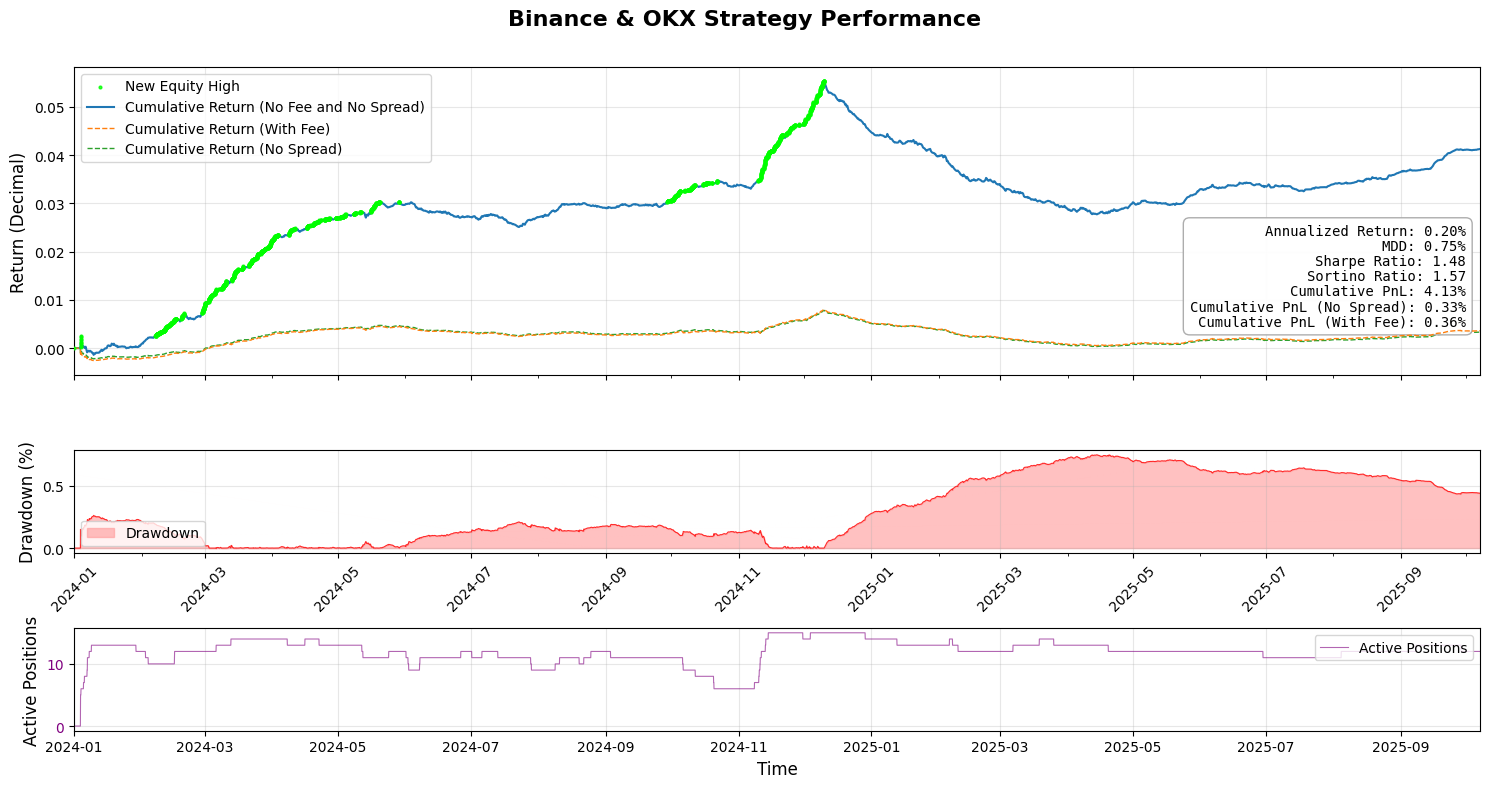

Plot: 15,489 points | 645 days | 2024-01-01 to 2025-10-07


In [14]:
binance_okx.plot_strategy_performance(portfolio_df,title="Binance & OKX Strategy Performance")

In [29]:
df,symbol = binance_okx.backtest_fundingrate(symbol='BTCUSDT', leverage=1,n_days=3, threshold=0.05,out_threshold=-0.1, value_threshold=3000000, value_out_threshold=1000000, start_date='2024-01-01')

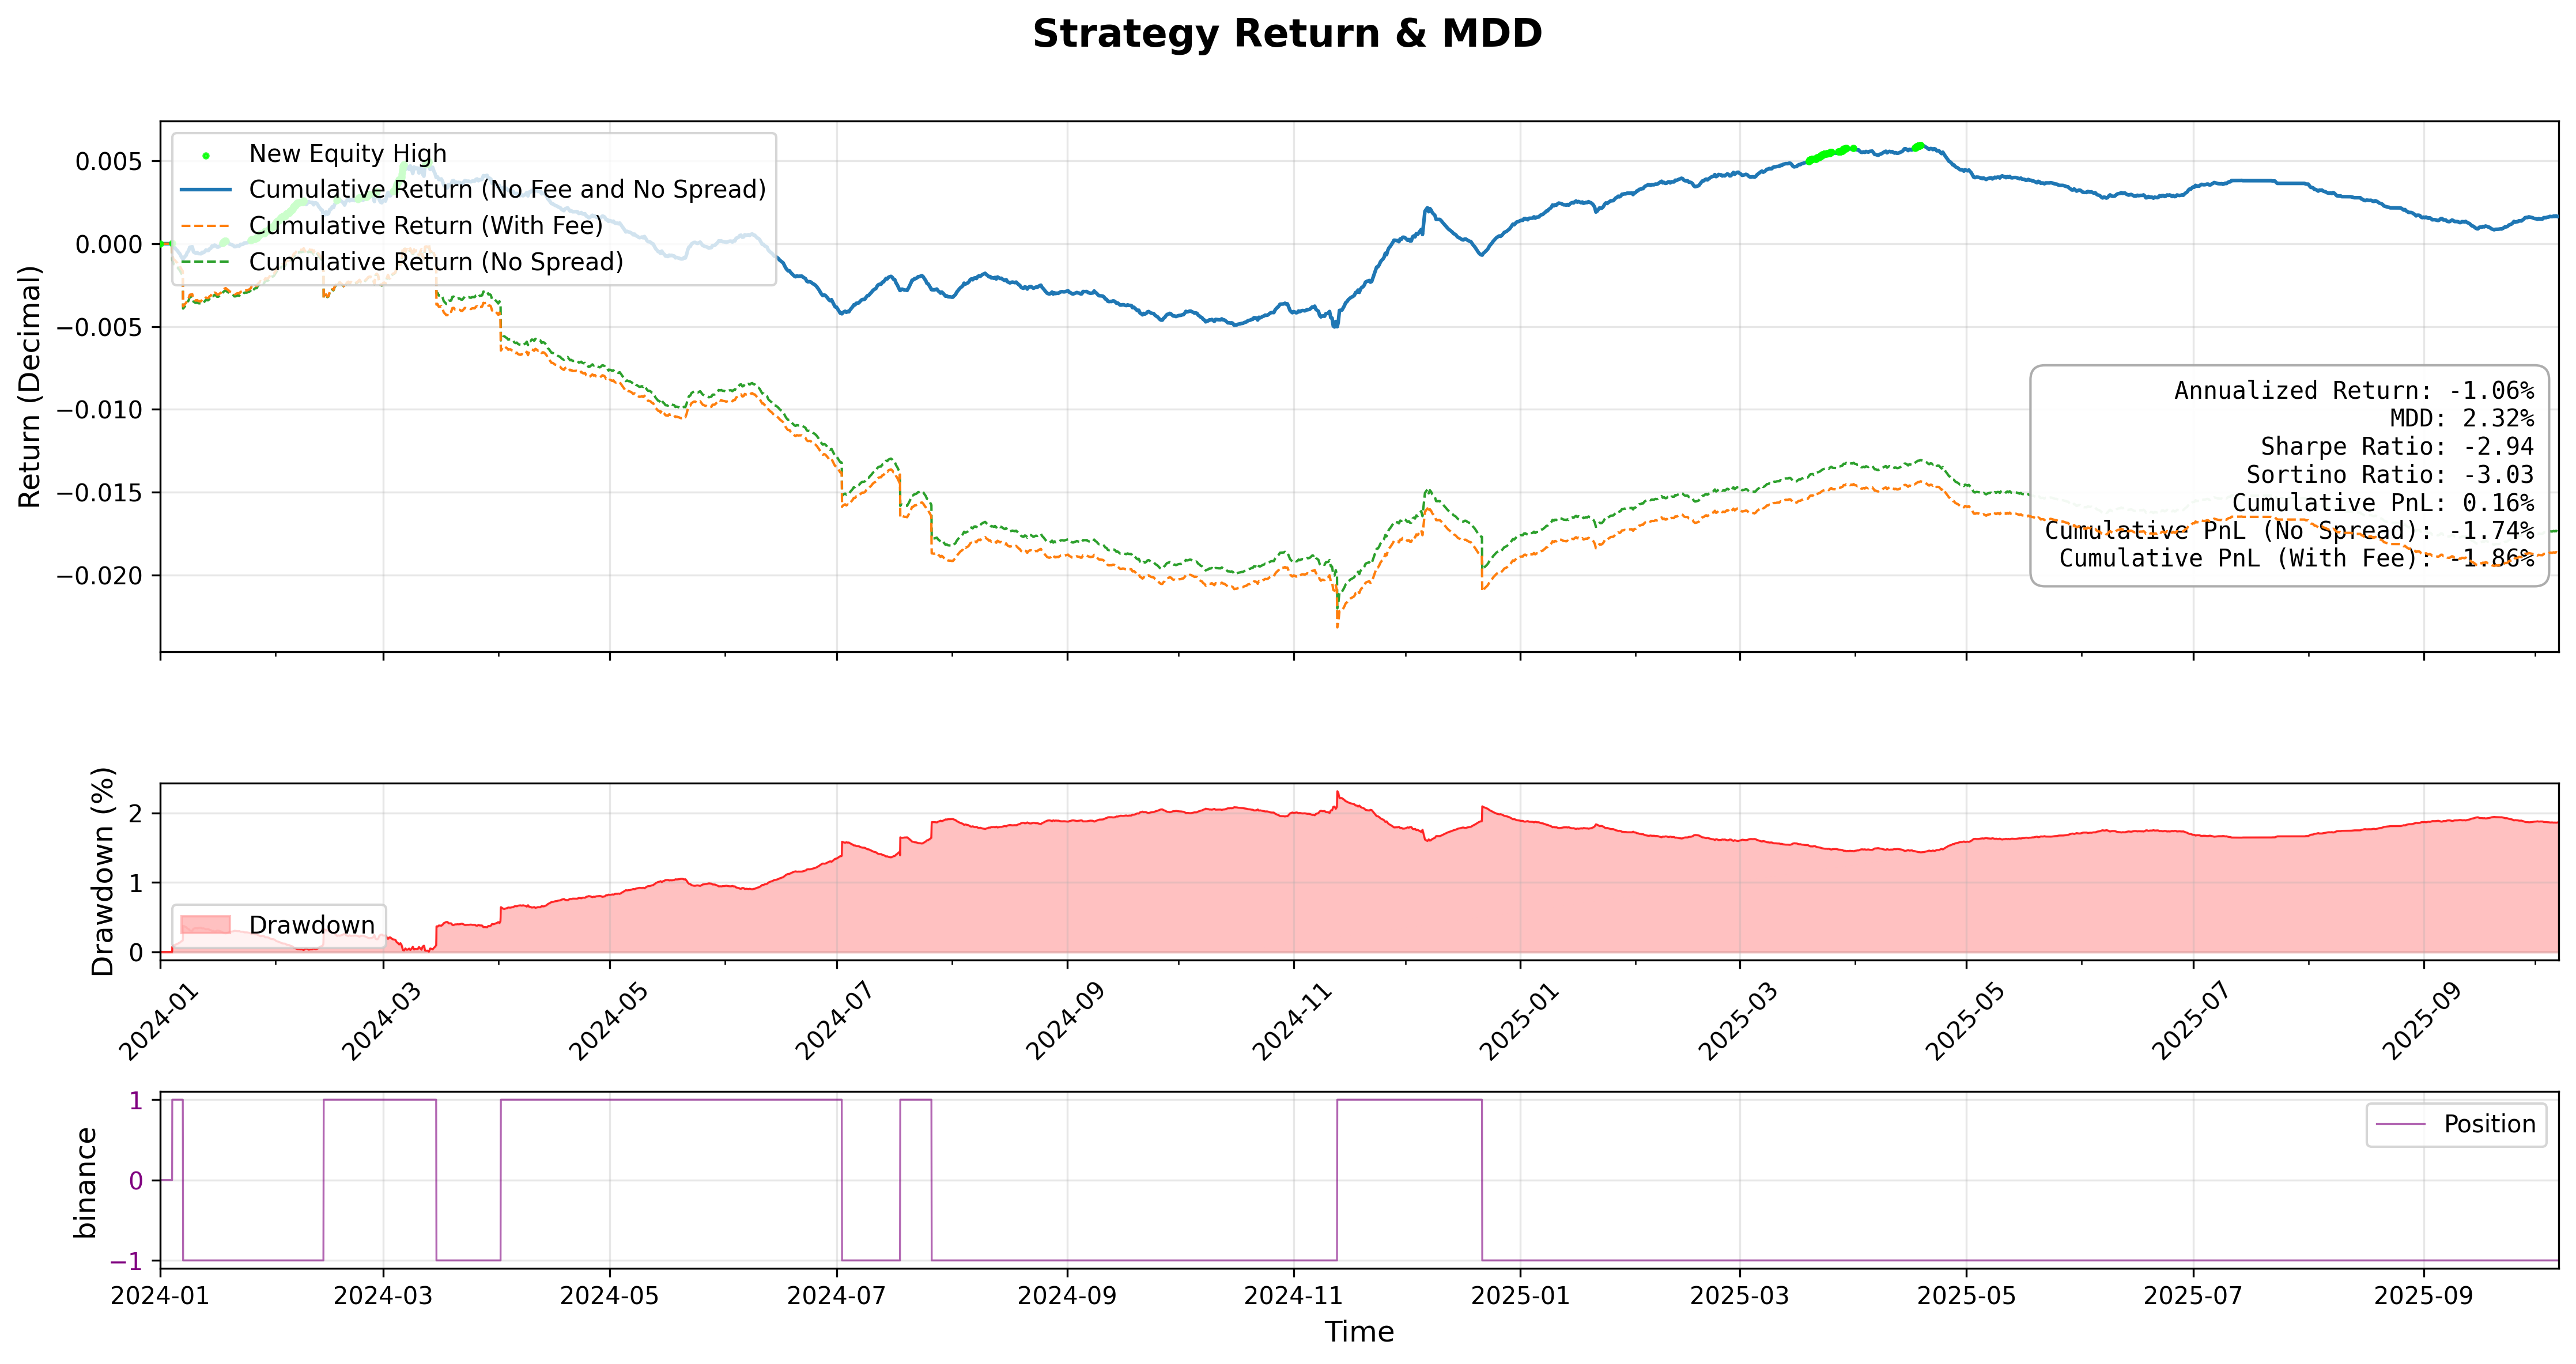

Plot: 15,489 points | 645 days | 2024-01-01 to 2025-10-07


In [30]:
binance_okx.plot_strategy_performance(df)

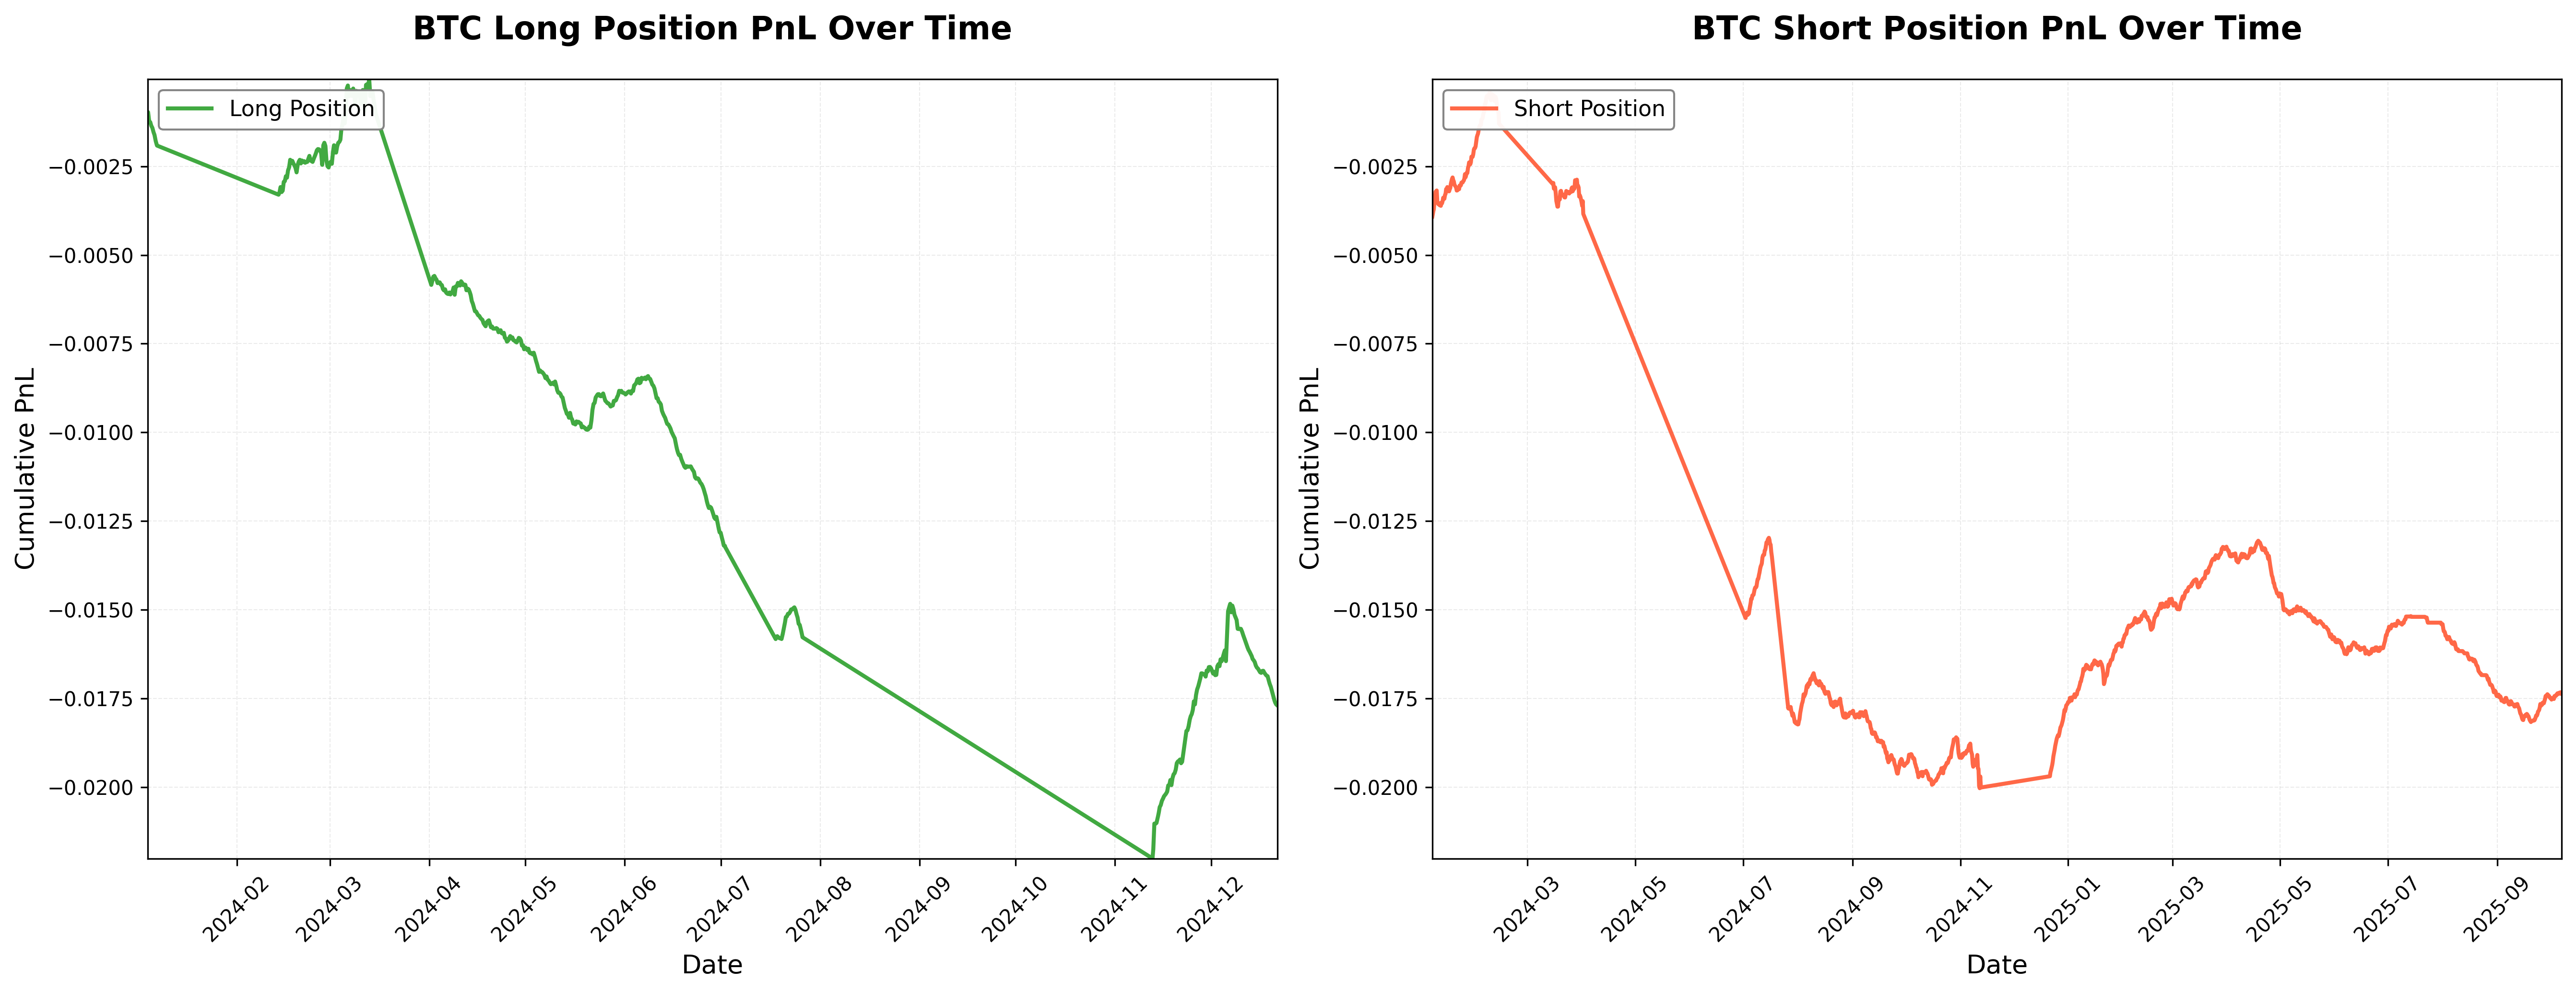

In [31]:
plot_long_ls(df,'BTC')

In [ ]:
for symbol in share_symbols:
    df,symbol = binance_okx.backtest_fundingrate(symbol=symbol, leverage=1,n_days=3, threshold=0.05,out_threshold=-0.1, value_threshold=3000000, value_out_threshold=1000000, start_date='2024-01-01')
    print(f"Results for {binance_okx.exchange1, symbol}: Long PnL, Short PnL = {L_S_analysis(df)}")
    binance_okx.plot_strategy_performance(df,title=f"Funding Rate Strategy Performance for {symbol}")
    plot_long_ls(df,symbol=symbol)

### binance & gateio

In [15]:
binance_gateio = Backtester(exchange1, exchange3)

Backtester: Cross-exchange mode: binance vs gateio | Symbols: 485


In [16]:
portfolio_df,stat,all_symbol_df,failed_symbols = binance_gateio.backtest_portfolio(symbols=share_symbols,max_active_positions=1000, leverage=1,n_days=3, threshold=0.10,out_threshold=-0.05, value_threshold=3000000, value_out_threshold=1000000)

Processing symbols: 100%|██████████| 15/15 [00:01<00:00, 10.61it/s]



Merging 15 symbols...
✓ Merge completed | Success: 15/15 | Failed: 0


Processing rows: 100%|██████████| 41769/41769 [00:01<00:00, 40473.95it/s]


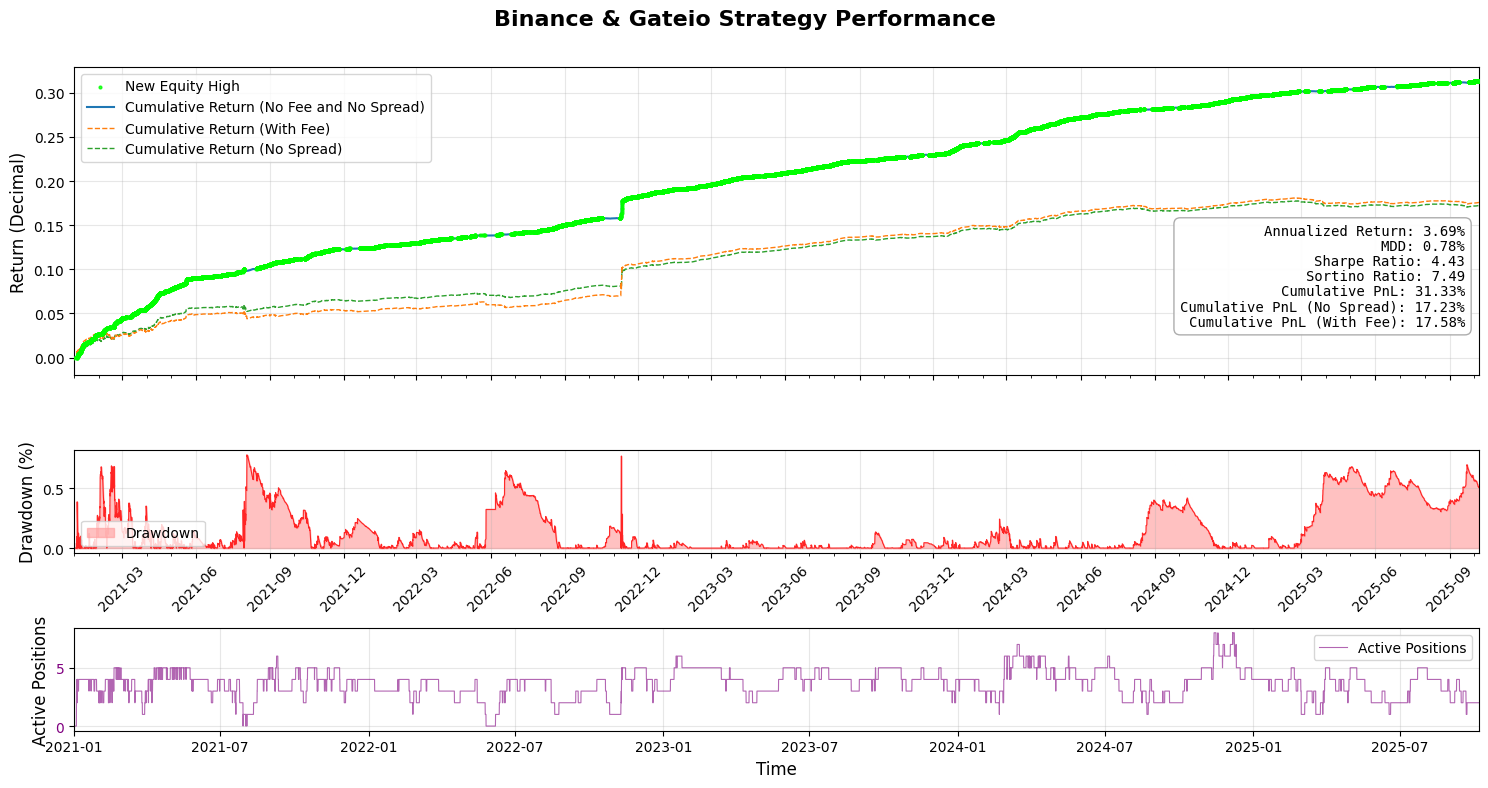

Plot: 41,769 points | 1740 days | 2021-01-01 to 2025-10-07


In [17]:
binance_gateio.plot_strategy_performance(portfolio_df,title="Binance & Gateio Strategy Performance")

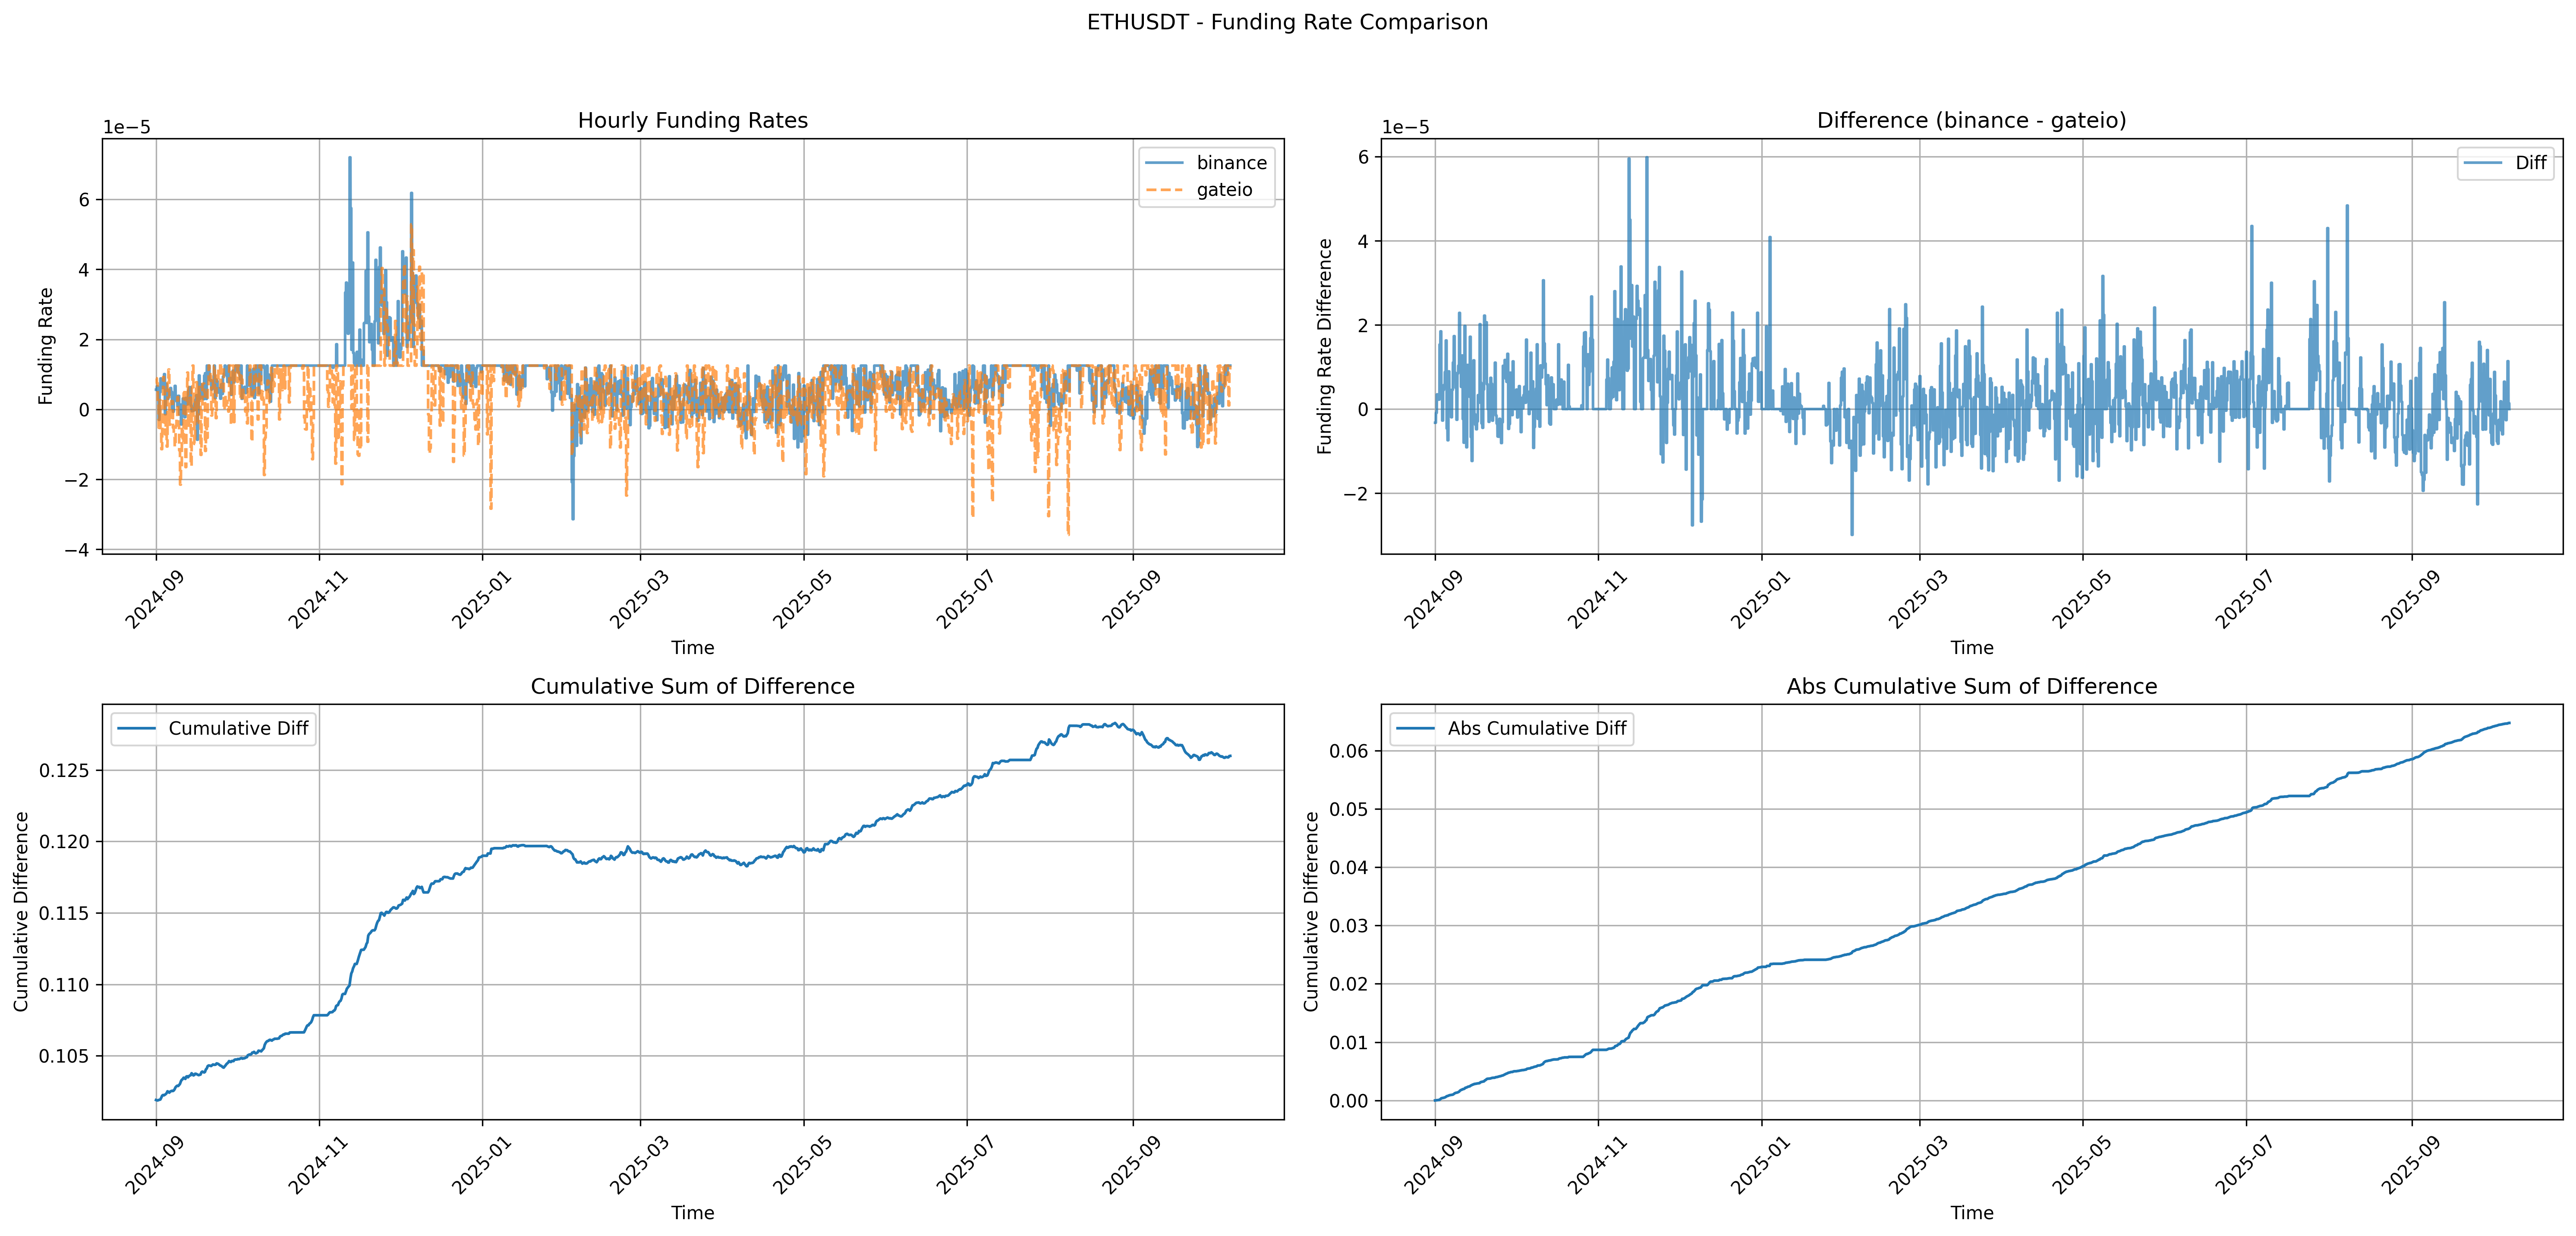

In [36]:
binance_gateio.plot_symbols(symbol='ETHUSDT',start_date='2024-09-01')

In [ ]:
for symbol in share_symbols:
    df,symbol = binance_gateio.backtest_fundingrate(symbol=symbol, leverage=1,n_days=3, threshold=0.05,out_threshold=-0.1, value_threshold=3000000, value_out_threshold=1000000, start_date='2024-09-01')
    print(f"Results for {binance_gateio.exchange1, symbol}: Long PnL, Short PnL = {L_S_analysis(df)}")
    binance_gateio.plot_strategy_performance(df,title=f"Funding Rate Strategy Performance for {symbol}")
    plot_long_ls(df,symbol=symbol)

### gateio & okx

In [18]:
gateio_okx = Backtester('gateio', 'okx')

Backtester: Cross-exchange mode: gateio vs okx | Symbols: 242


In [19]:
portfolio_df,stat,all_symbol_df,failed_symbols = gateio_okx.backtest_portfolio(symbols=share_symbols,max_active_positions=1000, leverage=1,n_days=2, threshold=0.10,out_threshold=-0.05, value_threshold=3000000, value_out_threshold=1000000)

Processing symbols:   0%|          | 0/15 [00:00<?, ?it/s]

Processing symbols: 100%|██████████| 15/15 [00:00<00:00, 34.42it/s]



Merging 15 symbols...
✓ Merge completed | Success: 15/15 | Failed: 0


Processing rows: 100%|██████████| 42153/42153 [00:01<00:00, 37060.13it/s]


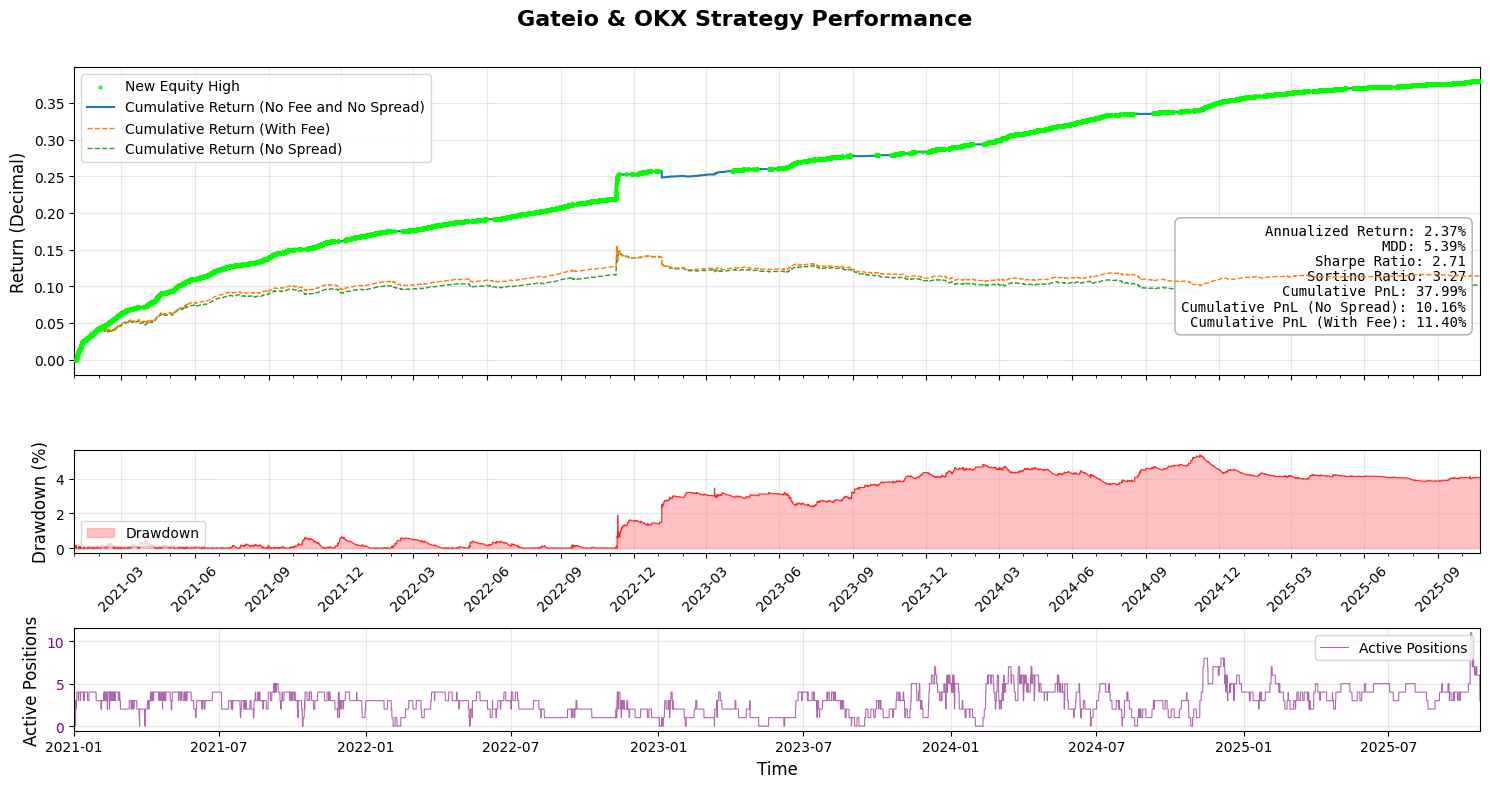

Plot: 42,153 points | 1756 days | 2021-01-01 to 2025-10-23


In [20]:
gateio_okx.plot_strategy_performance(portfolio_df,title="Gateio & OKX Strategy Performance")

In [8]:
df, symbol = gateio_okx.backtest_fundingrate(symbol='SOLUSDT', leverage=1, n_days=2, threshold=0.05, out_threshold=0.01, value_threshold=3000000, value_out_threshold=1000000)

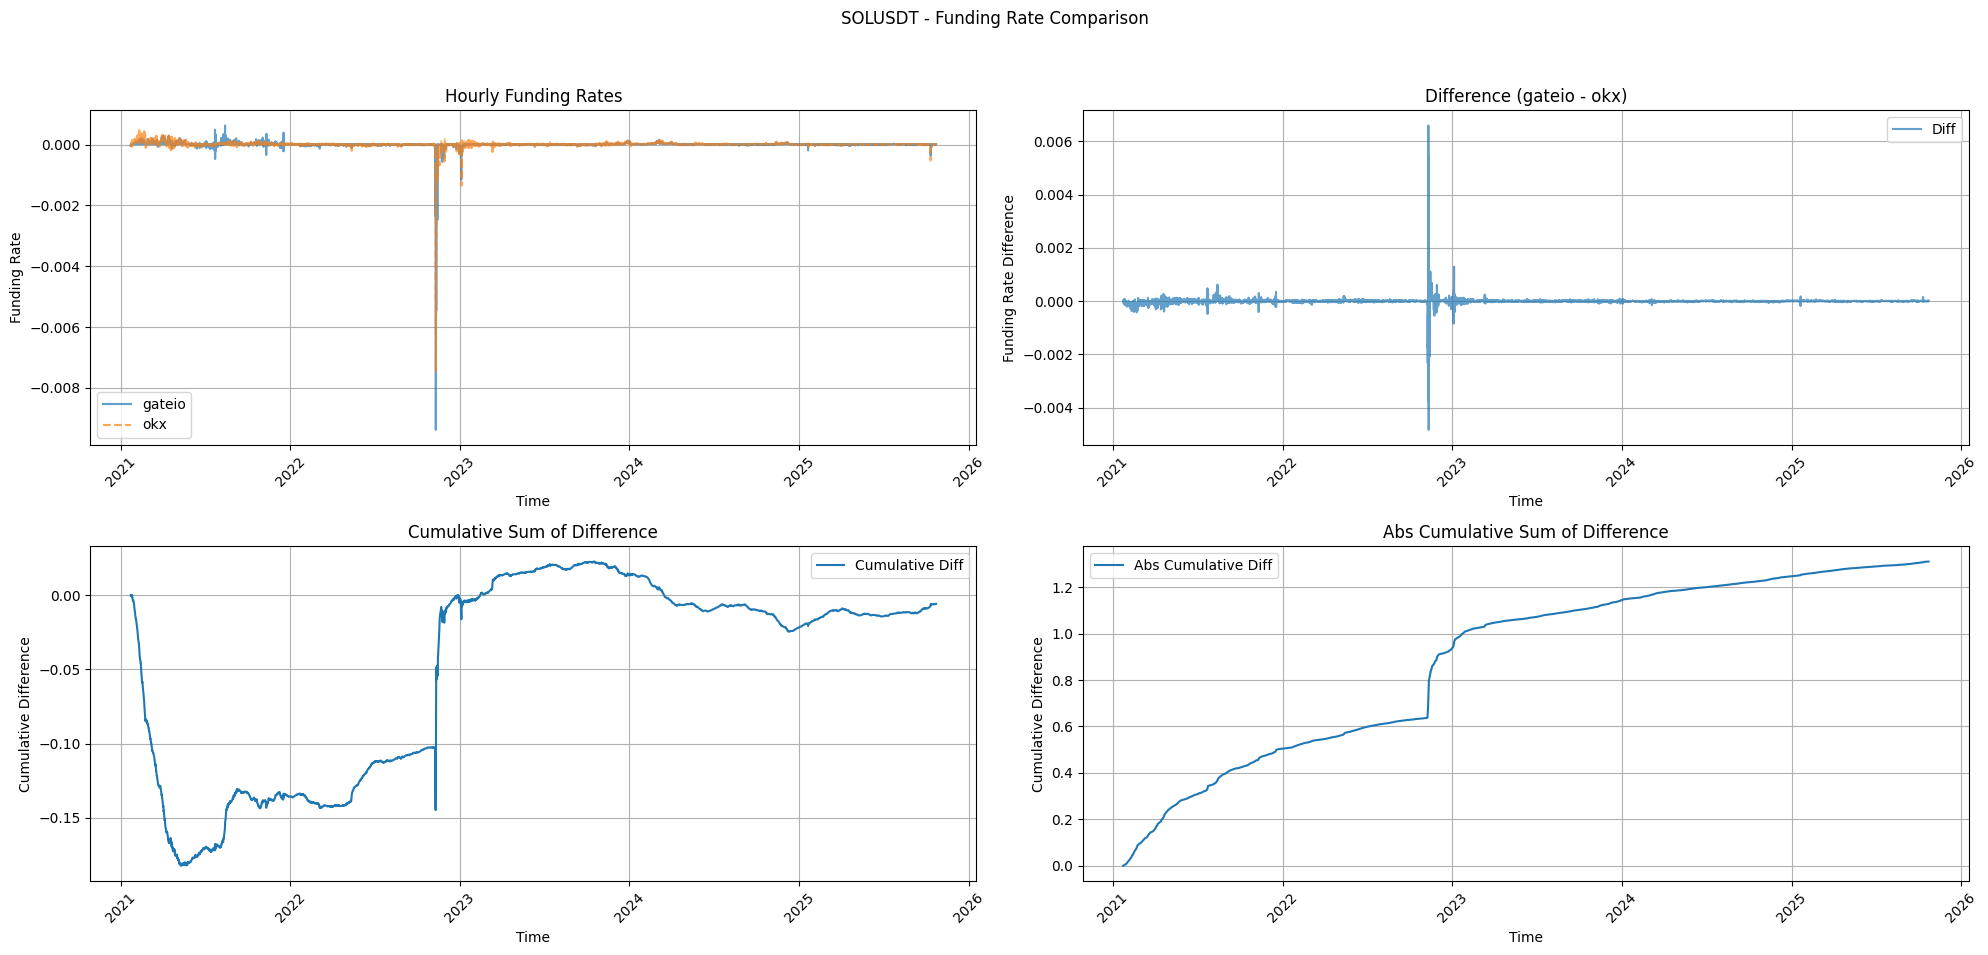

In [6]:
gateio_okx.plot_symbols(symbol='SOLUSDT')

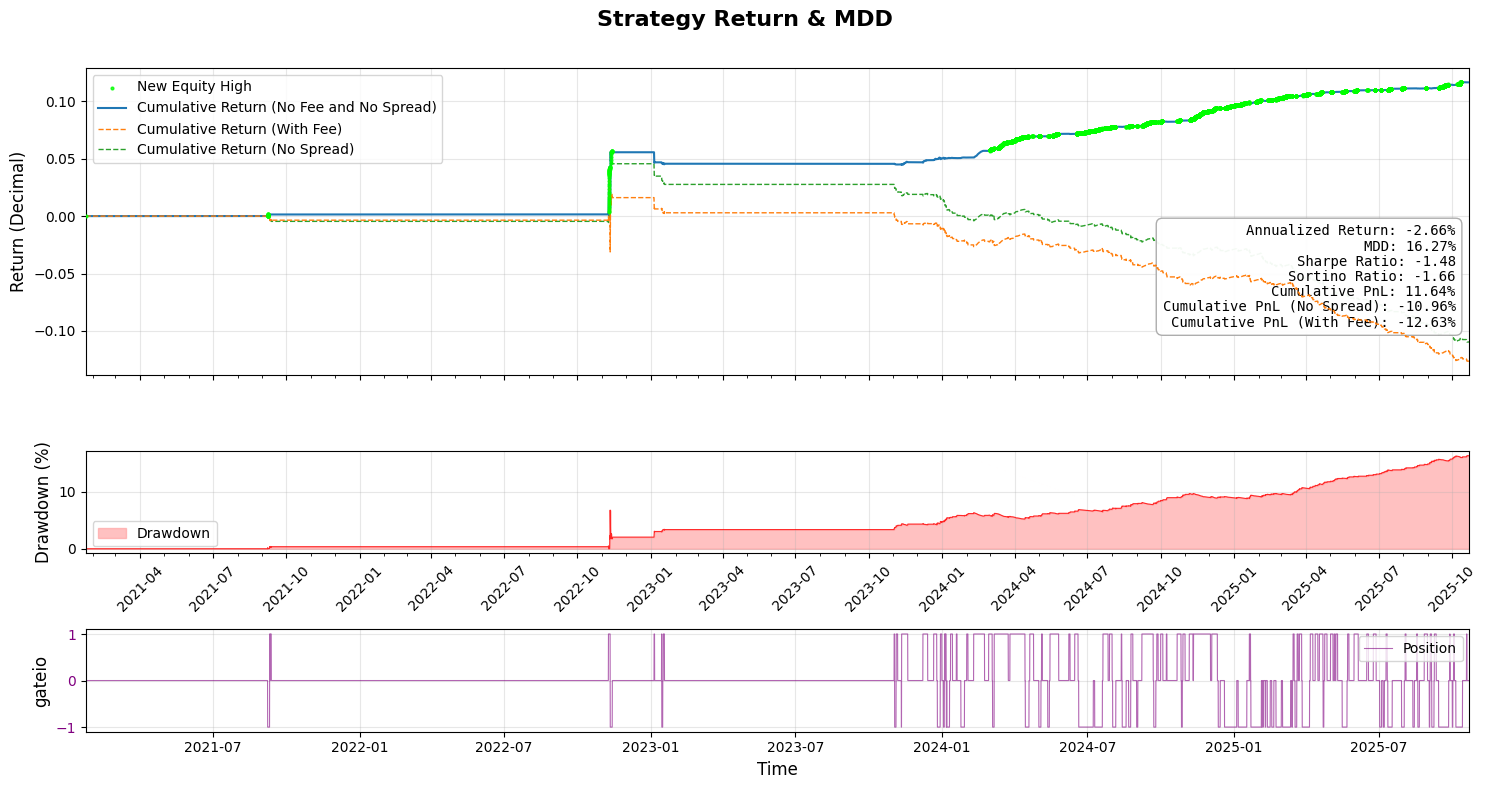

Plot: 41,625 points | 1734 days | 2021-01-22 to 2025-10-23


In [9]:
gateio_okx.plot_strategy_performance(df)